In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
import matplotlib.pyplot as plt
from tensorflow.keras.losses import CategoricalCrossentropy
import tensorflow as tf
from tensorflow.keras import layers, regularizers, optimizers, losses, Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier


era5 = xr.open_dataset(r"D:\\Documents\\thesis\\processed_data\\era5-land-all-variables\\era5land_ebro_daily_mean3.nc")
df = era5.to_dataframe()

df['day_of_year'] = df.index.dayofyear

# Ensure time column is datetime and extract the month
df['time'] = pd.to_datetime(df.index)
df['month'] = df['time'].dt.month
# This helps the model understand that Dec and Jan are neighbors
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Calculate Mean and Std Dev per month (and per pixel/station if applicable)
stats = df.groupby('month')['swvl1'].agg(['mean', 'std']).reset_index()

# Merge stats back to original dataframe
df = df.merge(stats, on='month')

# Calculate Z-score
df['z_score'] = (df['swvl1'] - df['mean']) / df['std']

# Create Buckets
bins = [-float('inf'), -1.5, -0.5, 0.5, 1.5, float('inf')]
labels = ['Severely Dry', 'Moderately Dry', 'Normal', 'Moderately Wet', 'Severely Wet']
labels = [0, 1, 2, 3, 4]
df['category'] = pd.cut(df['z_score'], bins=bins, labels=labels).astype(int)
df["target_next_month"] = df["category"].shift(-30)
df['tp_30d_sum'] = df['tp'].rolling(window=30, center=False).sum()
df['tp_90d_sum'] = df['tp'].rolling(window=90, center=False).sum()
df = df.dropna()

features_to_drop = ['z_score', 'target_next_month', 'time', 'mean'] 

top_features = ['swvl1', 'sro', 'std', 'slhf', 'month_cos', 'd2m','swvl3', 'e', 'stl1', 'tp_30d_sum', 'category']

In [ ]:
def prepare_data_for_lead_time(df, lead_time, seq_length=30):
    """
    Dynamically shifts target, prepares 3D sequences, and calculates class weights.
    Returns both one-hot (for DL) and flat (for XGBoost) labels.
    """
    features_df = df[top_features]
    y_raw = df['category'].values
    X_raw = features_df.values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    X_seq, y_seq, y_persist = [], [], []

    for i in range(len(X_scaled) - seq_length - lead_time + 1):
        X_seq.append(X_scaled[i:i + seq_length])
        target_idx = i + seq_length + lead_time - 1
        y_seq.append(y_raw[target_idx])
        y_persist.append(y_raw[i + seq_length - 1])

    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq).astype(int)
    
    # One-hot encoding for Deep Learning
    y_encoded = to_categorical(y_seq, num_classes=5)

    split_idx = int(len(X_seq) * 0.8)

    X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
    y_train, y_test = y_encoded[:split_idx], y_encoded[split_idx:]
    
    # Flat labels for XGBoost and Weight calculation
    y_train_flat = y_seq[:split_idx]
    y_test_flat = y_seq[split_idx:]

    # Class weight calculation
    weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train_flat),
        y=y_train_flat
    )
    class_weights_dict = {i: weight for i, weight in enumerate(weights)}

    
    return X_train, X_test, y_train, y_test, y_train_flat, y_test_flat, class_weights_dict, y_persist[split_idx:]

# LSTM
def train_evaluate_lstm(X_train, X_test, y_train, y_test, weights_dict, lead_time):
    model = Sequential([
        layers.LSTM(16, input_shape=(X_train.shape[1], X_train.shape[2]),
                    kernel_regularizer=regularizers.l2(0.01),
                    recurrent_regularizer=regularizers.l2(0.01),
                    dropout=0.3, recurrent_dropout=0.2),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(5, activation='softmax')
    ])

    model.compile(optimizer='adam', loss=losses.CategoricalCrossentropy(label_smoothing=0.1), metrics=['accuracy'])
    
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    model.fit(X_train, y_train, epochs=100, batch_size=64, validation_data=(X_test, y_test),
              callbacks=[early_stop], class_weight=weights_dict, verbose=0)

    acc = accuracy_score(np.argmax(y_test, axis=1), np.argmax(model.predict(X_test), axis=1))
    f1 = f1_score(np.argmax(y_test, axis=1), np.argmax(model.predict(X_test), axis=1), average='macro')
    return acc, f1, model

# CNN
def build_regularized_cnn(input_shape):
    model = Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(32, 5, activation='relu', kernel_regularizer=regularizers.l2(0.01), padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),
        layers.Dropout(0.3),
        layers.Conv1D(64, 3, activation='relu', kernel_regularizer=regularizers.l2(0.01), padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),
        layers.GlobalAveragePooling1D(),
        layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        layers.Dropout(0.5),
        layers.Dense(5, activation='softmax')
    ])
    model.compile(optimizer=optimizers.Adam(0.001), loss=losses.CategoricalCrossentropy(label_smoothing=0.1), metrics=['accuracy'])
    return model

def train_evaluate_cnn(X_train, y_train, X_test, y_test, class_weights_dict, lead_time):
    model = build_regularized_cnn((X_train.shape[1], X_train.shape[2]))
    callbacks = [EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
                 ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)]

    model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32,
              class_weight=class_weights_dict, callbacks=callbacks, verbose=0)

    y_pred = np.argmax(model.predict(X_test), axis=1)
    acc = accuracy_score(np.argmax(y_test, axis=1), y_pred)
    f1 = f1_score(np.argmax(y_test, axis=1), y_pred, average='macro')
    return acc, f1, model

# TRANSFORMER
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.3):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Dense(ff_dim, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(inputs.shape[-1])(x)
    return x + res

def build_transformer_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=64, dropout=0.3)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(5, activation="softmax")(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def train_evaluate_transformer(X_train, y_train, X_test, y_test, class_weights_dict, lead_time):
    model = build_transformer_model((X_train.shape[1], X_train.shape[2]))
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    model.fit(X_train, y_train, epochs=100, batch_size=64, validation_data=(X_test, y_test),
              callbacks=[early_stop], class_weight=class_weights_dict, verbose=0)

    acc = accuracy_score(np.argmax(y_test, axis=1), np.argmax(model.predict(X_test), axis=1))
    f1 = f1_score(np.argmax(y_test, axis=1), np.argmax(model.predict(X_test), axis=1), average='macro')
    return acc, f1, model

# XGBOOST
def train_evaluate_xgboost(X_train, y_train_flat, X_test, y_test_flat, class_weights_dict, lead_time):
    """
    Applies weights by mapping the class_weight dict to a sample_weight array.
    Flattens 3D input to 2D for tree-based processing.
    """
    # Flatten 3D (samples, time, features) -> 2D (samples, time*features)
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_test_flat = X_test.reshape(X_test.shape[0], -1)

    # Create sample weights array based on y_train_flat
    sample_weights = np.array([class_weights_dict[t] for t in y_train_flat])

    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        objective='multi:softmax',
        num_class=5,
        random_state=42
    )

    model.fit(X_train_flat, y_train_flat, sample_weight=sample_weights)

    y_pred = model.predict(X_test_flat)
    acc = accuracy_score(y_test_flat, y_pred)
    f1 = f1_score(y_test_flat, y_pred, average='macro')
    return acc, f1, model

Starting Lead-Time Analysis...


c:\Users\albat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step



c:\Users\albat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 19s 145ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step


...

81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


c:\Users\albat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


c:\Users\albat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step

 LEAD-TIME PREDICTABILITY ANALYSIS 
 Lead Time (Days)  LSTM F1 Macro (%)  CNN F1 Macro (%)  Transformer F1 Macro (%)  XGBoost F1 Macro (%)  Persistence F1 Macro (%)
                1              71.18             79.19                     55.50                 76.60                     78.42
                2              58.01             63.91                     46.58                 63.72                     65.11
                3              46.91             51.74                     44.68                 55.52                     55.26
                4              42.48             41.01                     40.46                 47.55                     48.48
                5              39.22             39.18                     33.22                 43.25                

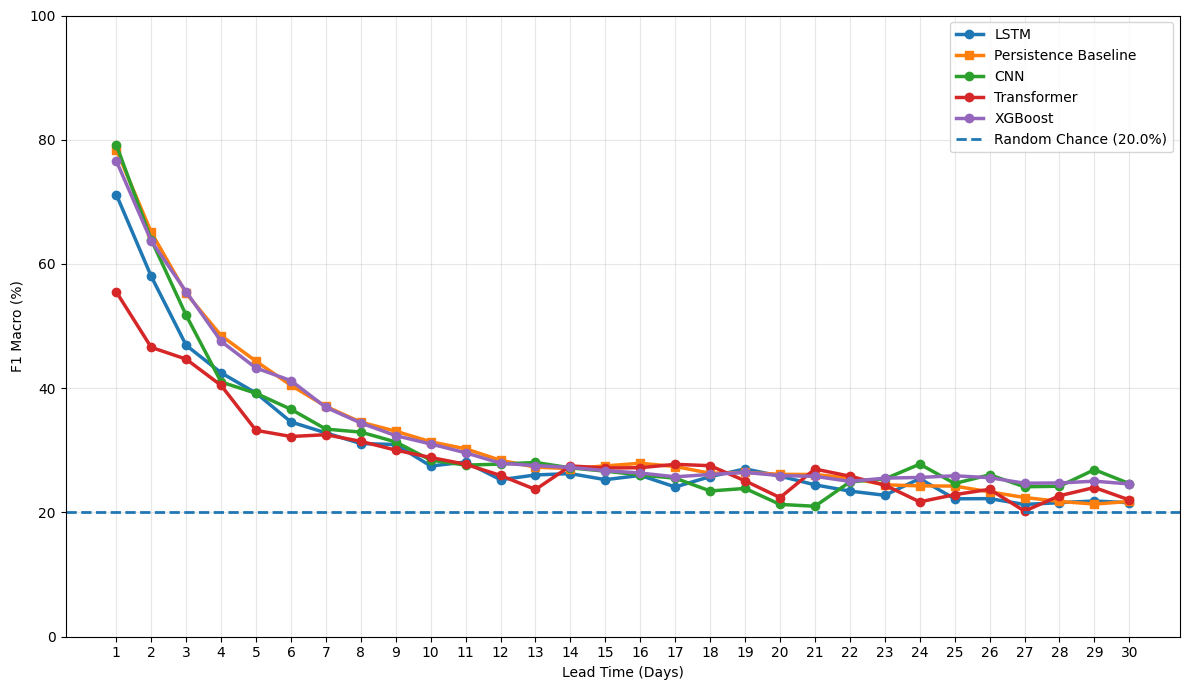

In [ ]:
def plot_hero_predictability(results_df):
    plt.figure(figsize=(12, 7))

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['LSTM F1 Macro (%)'],
        marker='o',
        linewidth=2.5,
        label='LSTM'
    )

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['Persistence F1 Macro (%)'],
        marker='s',
        linewidth=2.5,
        label='Persistence Baseline'
    )

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['CNN F1 Macro (%)'],
        marker='o',
        linewidth=2.5,
        label='CNN'
    )

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['Transformer F1 Macro (%)'],
        marker='o',
        linewidth=2.5,
        label='Transformer'
    )

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['XGBoost F1 Macro (%)'],
        marker='o',
        linewidth=2.5,
        label='XGBoost'
    )

    plt.axhline(
        y=20.0,
        linestyle='--',
        linewidth=2,
        label='Random Chance (20.0%)'
    )

    plt.xlabel('Lead Time (Days)')
    plt.ylabel('F1 Macro (%)')
    plt.xticks(results_df['Lead Time (Days)'])
    plt.ylim(0, 100)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


import gc

# MAIN EXECUTION LOOP
lead_times_to_test = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30] 
results_list = []

print("Starting Lead-Time Analysis...")

for lt in lead_times_to_test:
    X_train, X_test, y_train, y_test, y_train_flat, y_test_flat, class_weights, y_persist_test = prepare_data_for_lead_time(df, lead_time=lt)
    
    # LSTM
    val_acc_lstm, val_f1_lstm, _ = train_evaluate_lstm(X_train, X_test, y_train, y_test, class_weights, lead_time=lt)

    # Persistence
    persistence_acc = np.mean(y_persist_test == y_test_flat)
    persistence_f1 = f1_score(y_test_flat, y_persist_test, average='macro')

    # CNN
    val_acc_cnn, val_f1_cnn, _ = train_evaluate_cnn(X_train, y_train, X_test, y_test, class_weights, lead_time=lt)

    # transformer
    val_acc_transformer, val_f1_transformer, _ = train_evaluate_transformer(X_train, y_train, X_test, y_test, class_weights, lt)
    
    # XGboost
    # "Squash" X into 2D for XGBoost
    # This turns (Samples, 30, 11) into (Samples, 330)
    X_train_xgb = X_train.reshape(X_train.shape[0], -1)
    X_test_xgb = X_test.reshape(X_test.shape[0], -1)

    # Convert y back to Integers for XGBoost
    # Turns [[1,0,0], [0,1,0]] into [0, 1]
    y_train_xgb = np.argmax(y_train, axis=1)
    y_test_xgb = np.argmax(y_test, axis=1)

    val_acc_xgboost, val_f1_xgboost, _ = train_evaluate_xgboost(X_train_xgb, y_train_xgb, X_test_xgb, y_test_xgb, class_weights, lead_time=lt)

    results_list.append({
        'Lead Time (Days)': lt,
        'LSTM F1 Macro (%)': round(val_f1_lstm * 100, 2),
        'CNN F1 Macro (%)': round(val_f1_cnn * 100, 2),
        'Transformer F1 Macro (%)': round(val_f1_transformer * 100, 2),
        'XGBoost F1 Macro (%)': round(val_f1_xgboost * 100, 2),
        'Persistence F1 Macro (%)': round(persistence_f1 * 100, 2)
    })

    # CRITICAL: CLEAR MEMORY
    # Wipe the TensorFlow/Keras models from RAM/GPU
    tf.keras.backend.clear_session()
    
    # Delete the large data arrays to free up space
    del X_train, X_test, X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb, y_train, y_test
    
    # Force Python to clean up
    gc.collect()


results_df = pd.DataFrame(results_list)

print("\n" + "=" * 50)
print(" LEAD-TIME PREDICTABILITY ANALYSIS ")
print("=" * 50)
print(results_df.to_string(index=False))
print("=" * 50)

# Final hero plot
plot_hero_predictability(results_df)